
--- POINTS DISTRIBUTION ---
points
0     5
1    16
3    17
Name: count, dtype: int64

--- FIRST MATCHES ---
   match_n             team1  goals_team1                     team2  \
0        1          AC Milan            2           Bologna FC 1909   
1        2       Juventus FC            1           Bologna FC 1909   
2        3   Cagliari Calcio            1           Bologna FC 1909   
3        4  Hellas Verona FC            0           Bologna FC 1909   
4        5        SSC Napoli            0           Bologna FC 1909   
5        6          AC Monza            0           Bologna FC 1909   
6        7   Bologna FC 1909            3                 Empoli FC   
7        8   Bologna FC 1909            2  FC Internazionale Milano   

   goals_team2  points  
0            0       0  
1            1       1  
2            2       3  
3            0       1  
4            0       1  
5            0       1  
6            0       3  
7            2       1  

--- POINTS DISTRIBUTION -

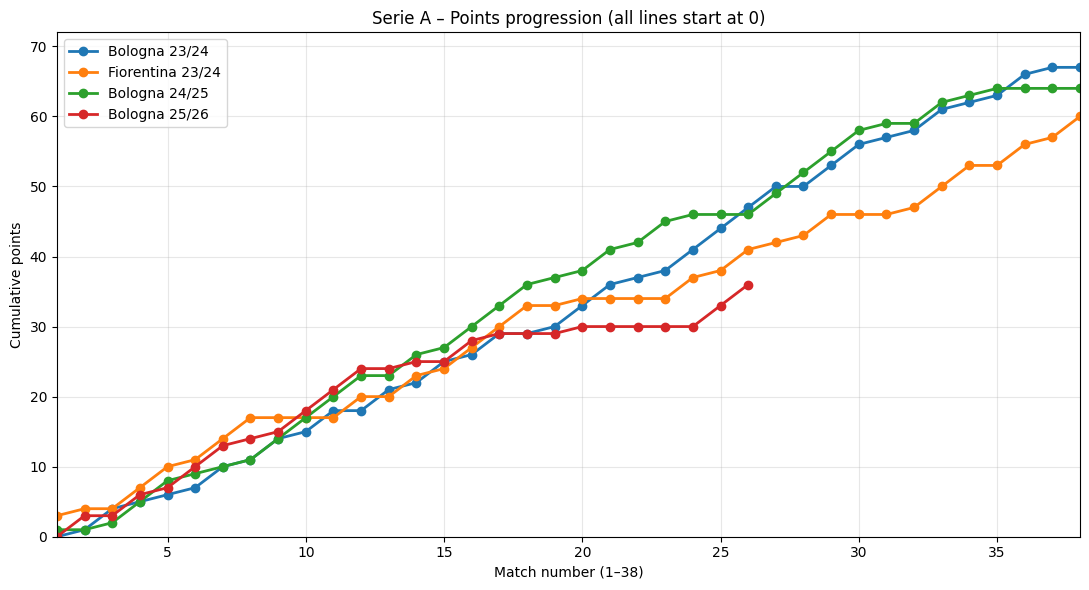

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------
# CONFIG: modifica SOLO questa sezione
# ---------------------------
SEASONS = [
    {
        "label": "Bologna 23/24",
        "folder": Path("/Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_23_24"),
        "team": "Bologna FC 1909",
    },
    {
        "label": "Fiorentina 23/24",
        "folder": Path("/Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_23_24"),
        "team": "ACF Fiorentina",
    },
    {
        "label": "Bologna 24/25",
        "folder": Path("/Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_24_25"),
        "team": "Bologna FC 1909",
    },
    {
        "label": "Bologna 25/26",
        "folder": Path("/Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_25_26"),
        "team": "Bologna FC 1909",
    },
]

MAX_MATCHES = 38

# Colonne minime (aggiungo event e type_id per goal detection robusta)
USECOLS = [
    "match_id",
    "team_name",
    "event",
    "type_id",
    "Scored",
    "own goal",
    "Goal disallowed",
    "week",
    "local_date",
    "local_time",
]


# ---------------------------
# HELPERS
# ---------------------------
def _safe_read_csv(csv_path: Path) -> pd.DataFrame:
    """Legge solo le colonne necessarie se esistono; fallback se alcune mancano."""
    try:
        df = pd.read_csv(csv_path, usecols=lambda c: c in set(USECOLS))
    except ValueError:
        df = pd.read_csv(csv_path)

    for col in USECOLS:
        if col not in df.columns:
            df[col] = pd.NA

    return df


def _get_two_teams(df: pd.DataFrame) -> list[str]:
    teams = df["team_name"].dropna().astype(str).unique().tolist()
    teams = [t.strip() for t in teams if str(t).strip() != ""]
    teams = list(dict.fromkeys(teams))
    if len(teams) != 2:
        raise ValueError(f"Non trovo esattamente 2 squadre nel match. Trovate: {teams[:10]}")
    return teams


def _coerce_flag(series: pd.Series) -> pd.Series:
    """Converte 0/1 in modo robusto anche se stringhe/NaN."""
    return pd.to_numeric(series, errors="coerce").fillna(0).astype(int)


def compute_score_from_events(df: pd.DataFrame) -> dict[str, int]:
    """
    Goal detection ROBUSTA:
    - Goal se event == "Goal" (case-insensitive) OR type_id == 16
    - esclude Goal disallowed == 1
    - gestisce own goal: assegna il goal all'avversaria
    """
    team1, team2 = _get_two_teams(df)
    goals = {team1: 0, team2: 0}

    goal_disallowed = _coerce_flag(df["Goal disallowed"]) if "Goal disallowed" in df.columns else pd.Series(0, index=df.index)
    own_goal = _coerce_flag(df["own goal"]) if "own goal" in df.columns else pd.Series(0, index=df.index)

    # event == "Goal"
    event_is_goal = pd.Series(False, index=df.index)
    if "event" in df.columns:
        event_is_goal = df["event"].astype(str).str.strip().str.lower().eq("goal")

    # type_id == 16 (Opta goal)
    type_is_goal = pd.Series(False, index=df.index)
    if "type_id" in df.columns:
        type_is_goal = (
            pd.to_numeric(df["type_id"], errors="coerce")
            .fillna(-1)
            .astype(int)
            .eq(16)
        )

    goal_mask = (event_is_goal | type_is_goal) & (goal_disallowed != 1)
    df_goals = df[goal_mask]

    if df_goals.empty:
        return goals

    for idx, row in df_goals.iterrows():
        scoring_team = str(row["team_name"]).strip()
        if scoring_team not in goals:
            continue

        og = int(own_goal.loc[idx]) if idx in own_goal.index else 0
        if og == 1:
            other = team2 if scoring_team == team1 else team1
            goals[other] += 1
        else:
            goals[scoring_team] += 1

    return goals


def compute_points_for_team(team: str, team1: str, team2: str, g1: int, g2: int):
    """Ritorna 3/1/0 per la squadra 'team' dato il risultato team1-team2."""
    if team not in (team1, team2):
        return None

    if team == team1:
        gf, ga = g1, g2
    else:
        gf, ga = g2, g1

    if gf > ga:
        return 3
    elif gf == ga:
        return 1
    else:
        return 0


def get_match_sort_key(df: pd.DataFrame, csv_path: Path):
    """
    Prova a usare:
    1) week (matchday)
    2) local_date + local_time
    3) nome file (fallback)
    """
    try:
        w = pd.to_numeric(df["week"].iloc[0], errors="coerce")
        if pd.notna(w):
            return ("week", int(w))
    except Exception:
        pass

    try:
        d = str(df["local_date"].iloc[0]) if pd.notna(df["local_date"].iloc[0]) else ""
        t = str(df["local_time"].iloc[0]) if pd.notna(df["local_time"].iloc[0]) else ""
        dt = pd.to_datetime((d + " " + t).strip(), errors="coerce")
        if pd.notna(dt):
            return ("datetime", dt)
    except Exception:
        pass

    return ("file", csv_path.name)


def build_season_points(folder: Path, team: str, label: str) -> pd.DataFrame:
    """
    Scansiona tutti i CSV in una cartella stagione (assunto: 1 file = 1 match),
    calcola punti match-by-match e cumulati.
    """
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Cartella non trovata: {folder}")

    rows = []
    # rglob per beccare CSV anche in sottocartelle
    csv_files = sorted(folder.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"Nessun CSV trovato in: {folder}")

    for csv_path in csv_files:
        df = _safe_read_csv(csv_path)

        match_id = df["match_id"].iloc[0] if df["match_id"].notna().any() else csv_path.stem

        team1, team2 = _get_two_teams(df)
        goals = compute_score_from_events(df)
        g1, g2 = goals[team1], goals[team2]

        pts = compute_points_for_team(team, team1, team2, g1, g2)
        if pts is None:
            continue

        key_type, key_value = get_match_sort_key(df, csv_path)

        rows.append(
            {
                "label": label,
                "season_folder": str(folder),
                "team": team,
                "match_id": match_id,
                "team1": team1,
                "team2": team2,
                "goals_team1": g1,
                "goals_team2": g2,
                "points": pts,
                "sort_key_type": key_type,
                "sort_key": key_value,
                "file": csv_path.name,
            }
        )

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError(f"Nessuna partita trovata per la squadra '{team}' in {folder}")

    # deduplica: se per qualche motivo leggi la stessa partita più volte
    if "match_id" in out.columns:
        out = out.drop_duplicates(subset=["match_id"], keep="first")

    # Ordina in modo stabile
    if (out["sort_key_type"] == "week").all():
        out = out.sort_values("sort_key")
    elif (out["sort_key_type"] == "datetime").any():
        # mette i datetime validi davanti e li ordina; poi fallback
        out = out.sort_values(["sort_key_type", "sort_key"], ascending=[False, True])
    else:
        out = out.sort_values("file")

    out = out.reset_index(drop=True)
    out["match_n"] = range(1, len(out) + 1)
    out["cum_points"] = out["points"].cumsum()

    return out


def plot_points_progression(dfs: list[pd.DataFrame]):
    plt.figure(figsize=(11, 6))

    for df in dfs:
        plt.plot(df["match_n"], df["cum_points"], marker="o", linewidth=2, label=df["label"].iloc[0])

    plt.xlabel("Match number (1–38)")
    plt.ylabel("Cumulative points")
    plt.title("Serie A – Points progression (all lines start at 0)")
    plt.xlim(1, MAX_MATCHES)

    # y dinamico: evita grafico schiacciato quando confronti stagioni/periodi corti
    max_y = max(d["cum_points"].max() for d in dfs)
    plt.ylim(0, max_y + 5)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def quick_debug(df_season: pd.DataFrame, n=10):
    """Debug rapido per capire se stai assegnando punti corretti."""
    print("\n--- POINTS DISTRIBUTION ---")
    print(df_season["points"].value_counts().sort_index())
    print("\n--- FIRST MATCHES ---")
    print(df_season.head(n)[["match_n", "team1", "goals_team1", "team2", "goals_team2", "points"]])


# ---------------------------
# RUN
# ---------------------------
all_dfs = []
for s in SEASONS:
    df_season = build_season_points(s["folder"], s["team"], s["label"])
    quick_debug(df_season, n=8)  # <-- togli pure quando sei ok
    all_dfs.append(df_season)

combined = pd.concat(all_dfs, ignore_index=True)

plot_points_progression(all_dfs)

# combined.to_csv("season_points_progression.csv", index=False)

In [2]:
import plotly_express as px

px.scatter(combined, x="match_n", y="cum_points", color="label")

In [3]:
import plotly.express as px

fig = px.line(
    combined,
    x="match_n",
    y="cum_points",
    color="label",
    markers=True  # <-- mantiene anche i pallini
)

fig.update_layout(
    title="Serie A – Points Progression",
    xaxis_title="Matchday",
    yaxis_title="Cumulative Points",
    template="plotly_white"
)

fig.show()

In [4]:
fig = px.line(
    combined,
    x="match_n",
    y="cum_points",
    color="label",
    markers=True
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    template="plotly_white",
    title="Season Points Progression",
    title_x=0.5,
    hovermode="x unified",
    xaxis=dict(
        dtick=1,
        range=[1, 38]
    ),
    yaxis=dict(
        rangemode="tozero"
    ),
    legend_title="Teams - Seasons"
)

fig.show()

In [5]:
import re
import plotly.express as px

# parole da ignorare (prefissi societari)
STOPWORDS = {
    "ac", "acf", "ssc", "fc", "us", "as", "ss",
    "calcio", "football", "club", "cfc",
    "1909", "1898", "1919", "1908"
}

def smart_abbr(name: str) -> str:
    name = str(name).lower().strip()

    # rimuove caratteri strani
    name = re.sub(r"[^a-z0-9\s]", " ", name)

    parts = [
        p for p in name.split()
        if p not in STOPWORDS and not p.isdigit()
    ]

    if not parts:
        return name[:3].upper()

    # prende l’ultima parola significativa
    main = parts[-1]

    return main[:3].upper()


# crea nuova colonna abbreviata
combined["match_abbr"] = (
    combined["team1"].apply(smart_abbr)
    + "-"
    + combined["team2"].apply(smart_abbr)
)


# Plot aggiornato
fig = px.line(
    combined,
    x="match_n",
    y="cum_points",
    color="label",
    markers=True,
    hover_data={
        "match_n": False,
        "label": False,
        "match_abbr": True,
        "cum_points": True,
    },
    labels={
        "match_abbr": "Match",
        "cum_points": "Cum points",
    },
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    template="plotly_white",
    title="Season Points Progression",
    title_x=0.5,
    hovermode="x unified",
    xaxis=dict(dtick=1, range=[1, 38]),
    yaxis=dict(rangemode="tozero"),
    legend_title="",
)

fig.show()